Data and dependency loading and basic description of data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
df.describe(include = 'all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [ ]:
df.shape

(48895, 16)

EDA

In [ ]:
missing = df.isnull().sum()
missing[missing > 0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


In [ ]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

<Axes: xlabel='room_type', ylabel='count'>

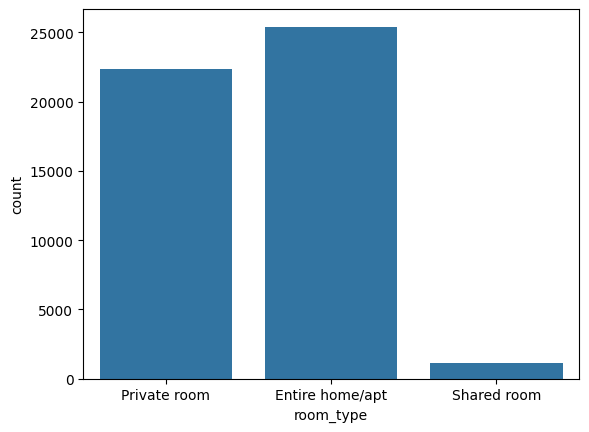

In [ ]:
df['room_type'].value_counts()

sns.countplot(x = 'room_type', data = df)

shared room has less data compared to other two which will create unbalace in our data and which will effect our model when we build the ml model and it will effect the performance of the model

In [ ]:
for col in df.columns:
    if df[col].dtype != 'object':
        numerical_cols.append(col)
    else:
        categorical_cols.append(col)

In [ ]:
numerical_cols

['price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'id',
 'host_id',
 'latitude',
 'longitude',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

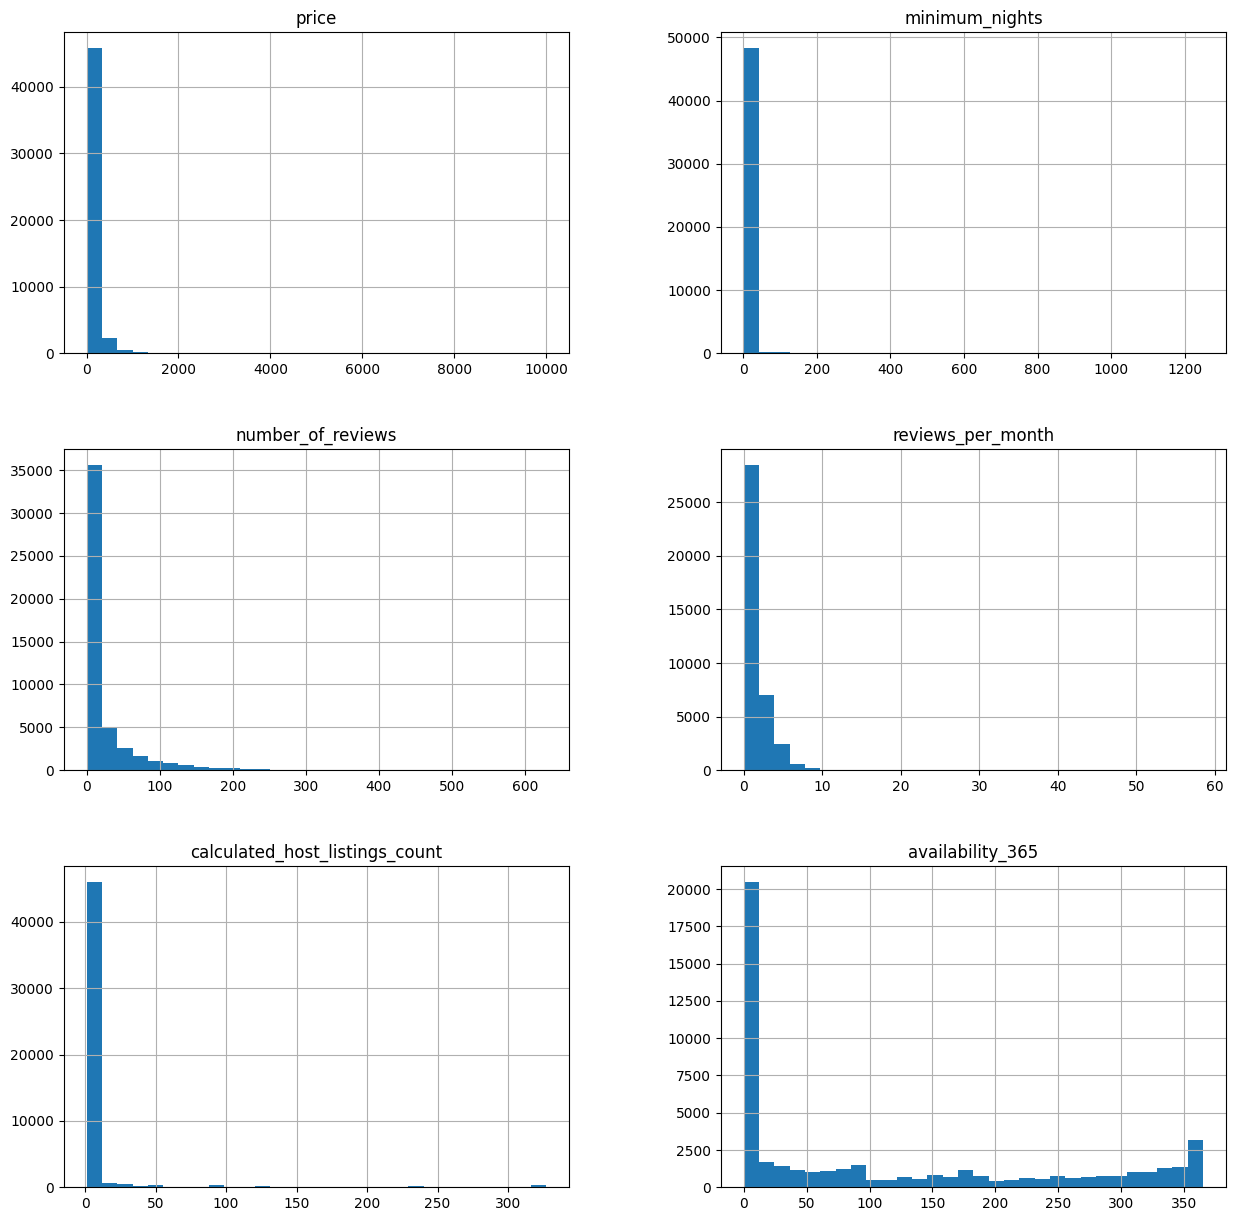

In [ ]:
numerical_cols = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]

df[numerical_cols].hist(figsize = (15,15), bins = 30)

<Axes: xlabel='neighbourhood_group', ylabel='count'>

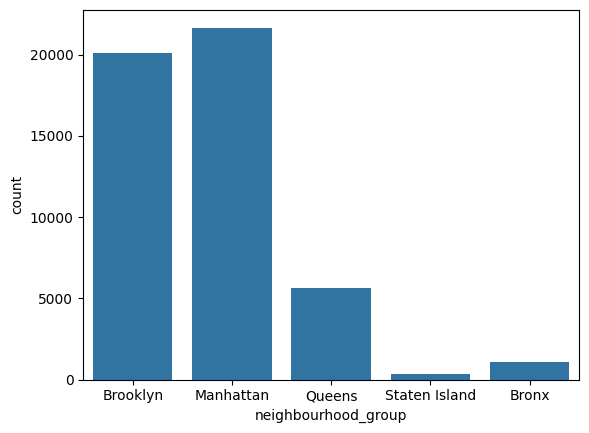

In [ ]:
sns.countplot(data = df, x = 'neighbourhood_group')

<Axes: xlabel='room_type', ylabel='price'>

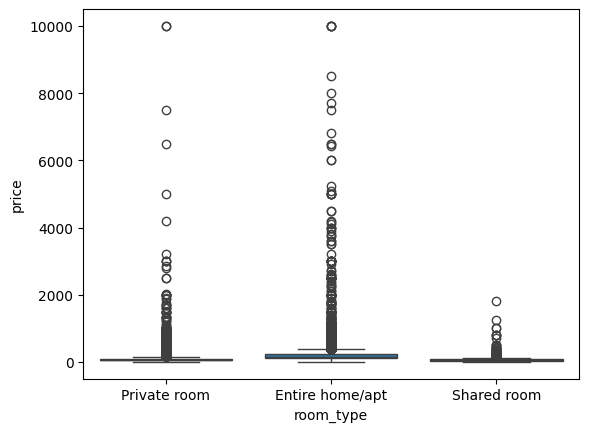

In [ ]:
sns.boxplot(x = 'room_type', y = 'price', data = df)

In [ ]:
corr = df[numerical_cols + ['latitude','longitude']].corr()
corr

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,latitude,longitude
price,1.000000,0.042799,-0.047954,-0.030608,0.057472,0.081829,0.033939,-0.150019
minimum_nights,0.042799,1.000000,-0.080116,-0.121702,0.127960,0.144303,0.024869,-0.062747
number_of_reviews,-0.047954,-0.080116,1.000000,0.549868,-0.072376,0.172028,-0.015389,0.059094
reviews_per_month,-0.030608,-0.121702,0.549868,1.000000,-0.009421,0.185791,-0.010142,0.145948
calculated_host_listings_count,0.057472,0.127960,-0.072376,-0.009421,1.000000,0.225701,0.019517,-0.114713
availability_365,0.081829,0.144303,0.172028,0.185791,0.225701,1.000000,-0.010983,0.082731
latitude,0.033939,0.024869,-0.015389,-0.010142,0.019517,-0.010983,1.000000,0.084788
longitude,-0.150019,-0.062747,0.059094,0.145948,-0.114713,0.082731,0.084788,1.000000


<Axes: >

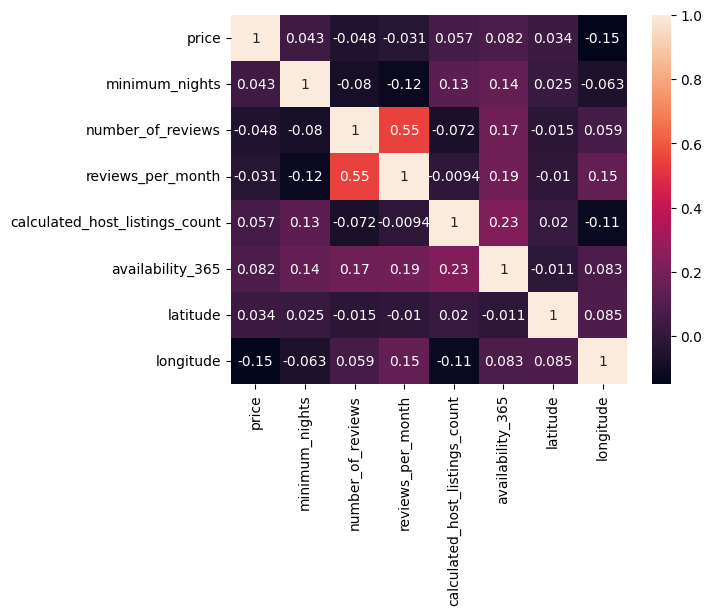

In [ ]:
sns.heatmap(corr, annot = True)

<Axes: xlabel='latitude', ylabel='longitude'>

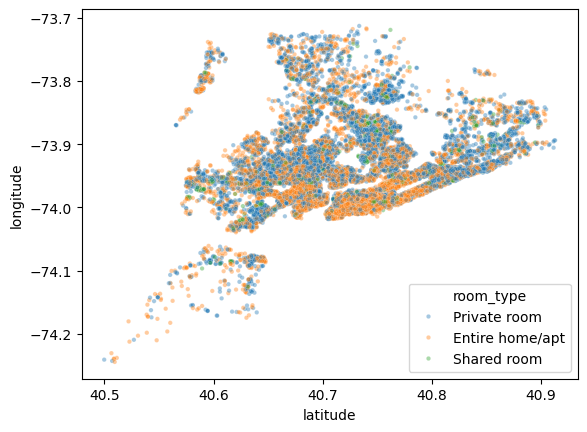

In [ ]:
sns.scatterplot(x = 'latitude', y = 'longitude' , hue = 'room_type', s = 10 , alpha = 0.4, data = df)

In [ ]:
df_clean = df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])
df_clean.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [ ]:
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [ ]:
price_cap = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper = price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper = nights_cap)

In [ ]:
x = df_clean.drop(columns = ['room_type'])
y = df_clean['room_type']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42, stratify=y)

preprocessing

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [ ]:
numerical_cols = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365", 'latitude','longitude']

categorical_cols = ['neighbourhood_group', 'neighbourhood']

In [ ]:
numerical_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

categorical_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))
])

preprocessor = ColumnTransformer(transformers = [
    ("numerical", numerical_pipline, numerical_cols),
    ("categorical", categorical_pipline, categorical_cols)
])

preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['price', 'minimum_nights',
                                  'number_of_reviews', 'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365', 'latitude',
                                  'longitude']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

Trying multiple Algorithm

**SMOTE (synthetic minority oversmapling)**

for class imbalance

1. high chances of overfitting.
2. data leakage

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
models = (
    "LogisticRegression", LogisticRegression(class_weight='balanced', random_state=42),
    "DecisionTreeClassifier", DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "RandomForestClassifier", RandomForestClassifier(class_weight='balanced', random_state=42),
    "GradientBoostingClassifier", GradientBoostingClassifier(random_state=42)
)

In [ ]:
for i in range(0, len(models), 2):
  name = models[i]
  model = models[i+1]
  pipe = Pipeline(steps = [
      ("preprocessor", preprocessor), # Use the new safe preprocessor
      ("classifier", model)
  ])

  accuracy = cross_val_score(pipe, x_train, y_train, cv = 3, scoring = "accuracy")
  macrof1 = cross_val_score(pipe, x_train, y_train, cv = 3, scoring = "f1_macro")

  print(f"{name} -> Accuracy: {accuracy.mean():.3f} , F1: {macrof1.mean():.3f}")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LogisticRegression -> Accuracy: 0.659 , F1: 0.522
DecisionTreeClassifier -> Accuracy: 0.783 , F1: 0.647
RandomForestClassifier -> Accuracy: 0.848 , F1: 0.713
GradientBoostingClassifier -> Accuracy: 0.850 , F1: 0.705


In [ ]:
from jax import random
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps = [
     ("preprocessor", preprocessor),
     ("classifier", RandomForestClassifier(class_weight='balanced', random_state=42))
 ])

param_distribtion = {
     "classifier__n_estimators": [100, 150, 200, 300],
     "classifier__max_depth": [None, 5, 10, 20],
     "classifier__min_samples_split": [2, 5, 10],
     "classifier__min_samples_leaf": [1, 2, 4]
}

search = RandomizedSearchCV(
    estimator= best_pipeline,
    param_distributions = param_distribtion,
    scoring = "f1_macro",
    n_iter = 10,
    cv = 3,
    random_state = 42,
)

search.fit(x_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365',
                                                                                'latitude',
                                                                                'longitude']),
                                                                              ('cat...
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   param_distributions={'classifier__max_depth': [None, 5, 10,
                                                                  20],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 150,
                                                                     200,
                                                                     300]},
                   random_state=42, scoring='f1_macro')

In [ ]:
print("Best parameters: ", search.best_params_)
print("Best f1  score: ", search.best_score_)

Best parameters:  {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': None}
Best f1  score:  0.7331779910736224


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

best_model = search.best_estimator_
y_pred = best_model.predict(x_test)

print(f"Accuracy score: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'macro')}")

Accuracy score: 0.8516360932077343
F1 score: 0.7450528807937941


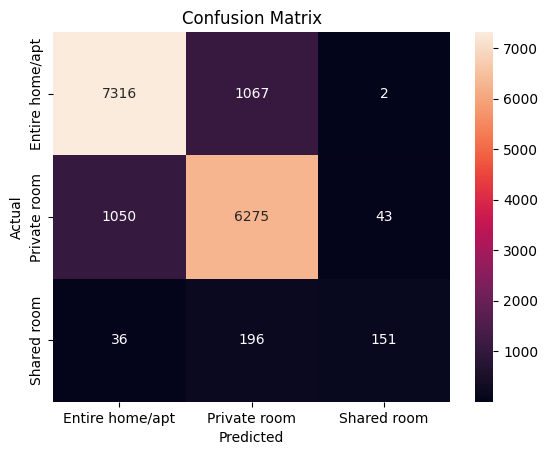

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import joblib

joblib.dump(best_pipeline, 'Model_Pipeline.pkl')

['Model_Pipeline.pkl']